# Sentiment Analysis with Hugging Face — Starter Notebook

This is the **unfinished / student version** of the notebook for the workshop.

In this notebook, you will learn how to:

1. Load a text dataset from Hugging Face.
2. Explore labels and class imbalance.
3. Tokenize text for a Transformer model.
4. Fine-tune a pretrained model for text classification.
5. Push the trained model to the Hugging Face Hub.
6. Use the trained model with the `pipeline` API.

> **Workshop note:** Some cells contain `TODO` sections. Complete them during the session.

## Step 1 — Environment Setup

Install the required libraries. In Colab, run this cell once at the beginning.

In [ ]:
!pip install -q -U datasets huggingface_hub fsspec "transformers>=4.41.0,<5.0.0" evaluate

## Step 2 — Load and Explore the Dataset

We will use a sentiment/emotion-related text dataset from Hugging Face.

For this workshop version, we use:

```python
dair-ai/emotion
```

This dataset contains English text samples labeled with emotion categories such as sadness, joy, love, anger, fear, and surprise.

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# TODO 1: Load the dataset from Hugging Face.
# Hint: use load_dataset("dair-ai/emotion", trust_remote_code=True)

emotions = load_dataset(_____, trust_remote_code=True)

display(emotions)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us kn

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
# TODO 2: Convert the training split to a pandas DataFrame.
# Hint: emotions["train"].to_pandas()

df = _____

display(df.head())

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


### Label Mapping

The dataset stores labels as integers. For interpretation, we convert them into readable class names.

In [ ]:
# TODO 3: Complete the function that maps integer labels to label names.
# Hint: emotions["train"].features["label"].int2str(...)

def int2str(row):
    return emotions["train"].features["label"].int2str(row["label"])

df["label_name"] = df.apply(int2str, axis=1)

display(df.head())

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Understanding Class Imbalance

Before training a model, it is important to check whether all classes are represented equally.

Class imbalance can affect model performance, especially for minority classes.

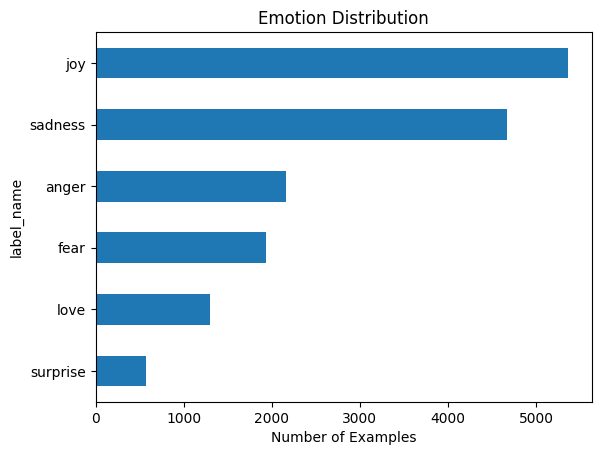

In [ ]:
# TODO 4: Plot the label distribution.
# Hint: use value_counts() on df["label_name"]

df[_____].value_counts(ascending=True).plot(
    kind="barh",
    title="Emotion Distribution"
)

plt.xlabel("Number of Examples")
plt.show()

In [ ]:
# TODO 5: Print the exact number of samples per label.

label_counts = df[_____].value_counts()
display(label_counts)

,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


> **Discussion Question:**  
> Which emotion labels are frequent? Which ones are rare?  
> How could this affect the model's predictions?

## Step 3 — Tokenization

Transformer models cannot directly process raw text.  
We need to convert text into numerical tokens using a tokenizer.

We will use the tokenizer that matches the pretrained model.

In [ ]:
from transformers import AutoTokenizer

# TODO 6: Choose the pretrained model checkpoint.
# Hint: "distilbert-base-uncased"

model_ckpt = _____

# TODO 7: Load the tokenizer.
tokenizer = AutoTokenizer.from_pretrained(_____)

tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [ ]:
# TODO 8: Complete the tokenize function.
# Hint: tokenize examples["text"] and use truncation=True

def tokenize(examples):
    return tokenizer(_____, truncation=True)

# TODO 9: Apply tokenization to the full dataset using map().
# Hint: emotions.map(tokenize, batched=True, batch_size=None)

emotions_encoded = emotions.map(_____, batched=True, batch_size=None)

display(emotions_encoded)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## Step 4 — Prepare the Model

Now we load a pretrained DistilBERT model and add a classification head for our emotion labels.

In [ ]:
from transformers import TFAutoModelForSequenceClassification

# Label mappings for the emotion dataset
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

label2id = {v: k for k, v in id2label.items()}

# TODO 10: Load a TensorFlow sequence classification model.
# Hint:
# TFAutoModelForSequenceClassification.from_pretrained(
#     model_ckpt,
#     num_labels=6,
#     id2label=id2label,
#     label2id=label2id,
#     from_pt=True
# )

model = TFAutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    from_pt=True
)

model.summary()

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSeq

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  4614      
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
Total params: 66958086 (255.42 MB)
Trainable params: 66958086 (255.42 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Step 5 — Prepare TensorFlow Datasets

The model expects batches of tokenized inputs.  
We use a data collator to dynamically pad sequences in each batch.

In [ ]:
from transformers import DataCollatorWithPadding
import tensorflow as tf

data_collator_np = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="np"
)

def custom_collate_fn(features):
    batch_np = data_collator_np(features)
    batch_tf = {k: tf.convert_to_tensor(v) for k, v in batch_np.items()}
    return batch_tf

# TODO 11: Convert the training split to a TensorFlow dataset.
# Hint: use emotions_encoded["train"].to_tf_dataset(...)

tf_train_set = emotions_encoded["train"].to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["labels"],
    shuffle=True,
    batch_size=16, # Example batch size, can be adjusted
    collate_fn=custom_collate_fn
)

# TODO 12: Convert the validation split to a TensorFlow dataset.

tf_validation_set = emotions_encoded["validation"].to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["labels"],
    shuffle=False,
    batch_size=16, # Example batch size, can be adjusted
    collate_fn=custom_collate_fn
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:419: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


## Step 6 — Training Setup

We define the evaluation metric and compile the model.

For a short workshop, you may use only 1 epoch or a small subset of the dataset to save time.

In [ ]:
import evaluate
import numpy as np
from transformers.keras_callbacks import KerasMetricCallback

accuracy = evaluate.load("accuracy")

# TODO 13: Complete the metric function.
# Hint: predictions should be converted to class IDs using np.argmax(..., axis=1)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# TODO 14: Choose a learning rate.
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

model.compile(optimizer=optimizer)

metric_callback = KerasMetricCallback(
    metric_fn=compute_metrics,
    eval_dataset=tf_validation_set
)

## Step 7 — Train the Model

Training may take time depending on the runtime environment.

> For the live workshop, keep `epochs=1` unless you have enough GPU time.

In [ ]:
# TODO 15: Train the model.
# Hint: model.fit(...)

history = model.fit(
    x=_____,
    validation_data=_____,
    epochs=_____,
    callbacks=[metric_callback]
)

Epoch 1/3
1000/1000 [==============================] - 141s 117ms/step - loss: 0.3691 - val_loss: 0.1963 - accuracy: 0.9250
Epoch 2/3
1000/1000 [==============================] - 99s 99ms/step - loss: 0.1413 - val_loss: 0.1565 - accuracy: 0.9330
Epoch 3/3
1000/1000 [==============================] - 98s 98ms/step - loss: 0.1077 - val_loss: 0.1424 - accuracy: 0.9370


## Step 8 — Push to the Hugging Face Hub

This step is optional during the workshop.

To push your model, you need a Hugging Face account and a token with write permission.

In [ ]:
from huggingface_hub import notebook_login

# TODO 16: Login to Hugging Face.
# Run this cell and paste your token when prompted.

# notebook_login()

In [ ]:
# TODO 17: Push the model and tokenizer to the Hub.
# Replace YOUR_MODEL_NAME with a meaningful name.
# Example: "emotion-analysis-distilbert-workshop"

# model.push_to_hub("YOUR_MODEL_NAME")
# tokenizer.push_to_hub("YOUR_MODEL_NAME")

## Step 9 — Inference with Pipeline

After training or loading a model from the Hub, we can use it with the `pipeline` API.

If you did not push your own model, you can use an existing Hugging Face model instead.

In [ ]:
from transformers import pipeline

# Option A: Use the local model and tokenizer from this notebook.
# TODO 18: Create a pipeline using model and tokenizer.

classifier = pipeline(
    task=_____,
    model=_____,
    tokenizer=_____
)

sample_text = "I watched a movie yesterday. It was really awesome!"

# TODO 19: Run the classifier on sample_text.
result = classifier(_____)

display(result)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Device set to use 0
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


[{'label': 'joy', 'score': 0.9730297327041626}]

In [ ]:
# TODO 20: Try your own examples.

examples = [
    "I am very excited about this workshop!",
    "I feel nervous and unsure about the exam.",
    "This is the worst day ever."
]

for text in examples:
    prediction = classifier(text)[0]
    print(f"Text: {text}")
    print(f"Prediction: {prediction['label']} | Confidence: {prediction['score']:.3f}")
    print("-" * 60)

Text: I am very excited about this workshop!
Prediction: joy | Confidence: 0.993
------------------------------------------------------------
Text: I feel nervous and unsure about the exam.
Prediction: fear | Confidence: 0.999
------------------------------------------------------------
Text: This is the worst day ever.
Prediction: sadness | Confidence: 0.437
------------------------------------------------------------


## Reflection Questions

1. Why do we tokenize text before using a Transformer model?
2. What problem can class imbalance create?
3. Why do we use a pretrained model instead of training from scratch?
4. What is the difference between training a model and using a pipeline for inference?
5. What should we be careful about before sharing a trained model on the Hugging Face Hub?

## Key Takeaway

Hugging Face allows us to move from dataset loading to model training and deployment within a single ecosystem.

However, model outputs should always be interpreted carefully, especially when dealing with subjective categories such as emotions or sentiment.